In [6]:
# ============================================================
# X-RAY VS NON-X-RAY DATASET PREPARATION
# KAGGLE VERSION
# ============================================================

import os
import shutil
import random

from sklearn.model_selection import train_test_split


# ============================================================
# SETTINGS
# ============================================================

# ------------------------------------------------------------
# Your chest X-ray dataset
# ------------------------------------------------------------

XRAY_SOURCE = (
    "/kaggle/input/datasets/rupdasgupta/pneumonia-no-preprocessed/Pnemonia_No_Preprocessed"
)


# ------------------------------------------------------------
# Your non-X-ray dataset
# ------------------------------------------------------------

NON_XRAY_SOURCE = (
    "/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV"
)


# ------------------------------------------------------------
# Output directory
#
# IMPORTANT:
# /kaggle/input/ is READ-ONLY
# Therefore output must be in /kaggle/working/
# ------------------------------------------------------------

OUTPUT_PATH = (
    "/kaggle/working/xray_verifier_dataset"
)


# ------------------------------------------------------------
# Classes
# ------------------------------------------------------------

CLASSES = [
    "Chest_Xray",
    "Non_Xray"
]


# ------------------------------------------------------------
# Valid image extensions
# ------------------------------------------------------------

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ============================================================
# CHECK INPUT PATHS
# ============================================================

print("=" * 70)
print("CHECKING DATASET PATHS")
print("=" * 70)


print("\nChest X-ray source:")
print(XRAY_SOURCE)

if not os.path.isdir(XRAY_SOURCE):

    raise FileNotFoundError(
        "\nChest X-ray dataset was not found.\n\n"
        f"Expected path:\n{XRAY_SOURCE}\n\n"
        "Check the dataset path under /kaggle/input/."
    )


print("\nNon-X-ray source:")
print(NON_XRAY_SOURCE)

if not os.path.isdir(NON_XRAY_SOURCE):

    print("\nERROR: Non-X-ray directory does not exist.")

    print("\nAvailable Kaggle datasets:")

    if os.path.isdir("/kaggle/input"):

        for item in os.listdir("/kaggle/input"):

            print(
                "  ",
                os.path.join(
                    "/kaggle/input",
                    item
                )
            )

    raise FileNotFoundError(
        "\nNon-X-ray dataset was not found.\n\n"
        f"Expected path:\n{NON_XRAY_SOURCE}\n\n"
        "Check the actual folder name under /kaggle/input/."
    )


# ============================================================
# FUNCTION: FIND IMAGES RECURSIVELY
# ============================================================

def find_images(root_directory):

    image_files = []

    for root, dirs, files in os.walk(
        root_directory
    ):

        for filename in files:

            if filename.lower().endswith(
                VALID_EXTENSIONS
            ):

                full_path = os.path.join(
                    root,
                    filename
                )

                image_files.append(
                    full_path
                )

    return image_files


# ============================================================
# FIND CHEST X-RAY IMAGES
# ============================================================

print("\n" + "=" * 70)
print("SEARCHING FOR CHEST X-RAY IMAGES")
print("=" * 70)


xray_files = []


for class_folder in [
    "Normal",
    "Pneumonia"
]:

    class_path = os.path.join(
        XRAY_SOURCE,
        class_folder
    )

    print(
        f"\nChecking: {class_path}"
    )

    if not os.path.isdir(class_path):

        print(
            f"WARNING: {class_folder} folder not found."
        )

        continue


    class_images = find_images(
        class_path
    )

    print(
        f"Found {len(class_images)} images "
        f"in {class_folder}"
    )

    xray_files.extend(
        class_images
    )


print(
    "\nTotal Chest X-ray images:",
    len(xray_files)
)


# ============================================================
# CHECK X-RAY DATA
# ============================================================

if len(xray_files) == 0:

    raise ValueError(
        "\nNo Chest X-ray images were found.\n\n"
        f"Checked path:\n{XRAY_SOURCE}\n\n"
        "Expected folders:\n"
        "  Normal/\n"
        "  Pneumonia/"
    )


# ============================================================
# FIND NON-X-RAY IMAGES
# ============================================================

print("\n" + "=" * 70)
print("SEARCHING FOR NON-X-RAY IMAGES")
print("=" * 70)


print(
    "\nSearching recursively inside:"
)

print(
    NON_XRAY_SOURCE
)


non_xray_files = find_images(
    NON_XRAY_SOURCE
)


print(
    "\nTotal Non-X-ray images:",
    len(non_xray_files)
)


# ============================================================
# DEBUG: SHOW NON-X-RAY SUBDIRECTORIES
# ============================================================

print("\nNon-X-ray dataset structure:")

for root, dirs, files in os.walk(
    NON_XRAY_SOURCE
):

    image_count = sum(
        1
        for f in files
        if f.lower().endswith(
            VALID_EXTENSIONS
        )
    )

    if image_count > 0:

        print(
            f"  {root}"
            f" --> {image_count} images"
        )


# ============================================================
# CHECK NON-X-RAY DATA
# ============================================================

if len(non_xray_files) == 0:

    raise ValueError(
        "\nNo Non-X-ray images were found.\n\n"
        f"Current Non-Xray path:\n"
        f"{NON_XRAY_SOURCE}\n\n"
        "The directory exists, but it contains "
        "no JPG/JPEG/PNG/BMP/WEBP images.\n\n"
        "Check the printed dataset structure above."
    )


# ============================================================
# SHOW SAMPLE FILES
# ============================================================

print("\nSample Chest X-ray files:")

for file_path in xray_files[:5]:

    print(
        "  ",
        file_path
    )


print("\nSample Non-X-ray files:")

for file_path in non_xray_files[:5]:

    print(
        "  ",
        file_path
    )


# ============================================================
# BALANCE DATASET
# ============================================================

print("\n" + "=" * 70)
print("BALANCING DATASET")
print("=" * 70)


print(
    f"\nChest X-ray images : {len(xray_files)}"
)

print(
    f"Non-X-ray images   : {len(non_xray_files)}"
)


minimum_count = min(
    len(xray_files),
    len(non_xray_files)
)


print(
    f"\nUsing {minimum_count} images "
    "from each class."
)


# Reproducibility
random.seed(42)


random.shuffle(
    xray_files
)

random.shuffle(
    non_xray_files
)


xray_files = xray_files[
    :minimum_count
]

non_xray_files = non_xray_files[
    :minimum_count
]


# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("CREATING TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)


def split_files(files):

    # 70% train
    # 30% temporary

    train_files, temp_files = train_test_split(

        files,

        test_size=0.30,

        random_state=42,

        shuffle=True
    )


    # 15% validation
    # 15% test

    val_files, test_files = train_test_split(

        temp_files,

        test_size=0.50,

        random_state=42,

        shuffle=True
    )


    return (
        train_files,
        val_files,
        test_files
    )


(
    xray_train,
    xray_val,
    xray_test
) = split_files(
    xray_files
)


(
    non_xray_train,
    non_xray_val,
    non_xray_test
) = split_files(
    non_xray_files
)


print(
    "\nChest X-ray:"
)

print(
    f"  Train      : {len(xray_train)}"
)

print(
    f"  Validation : {len(xray_val)}"
)

print(
    f"  Test       : {len(xray_test)}"
)


print(
    "\nNon-X-ray:"
)

print(
    f"  Train      : {len(non_xray_train)}"
)

print(
    f"  Validation : {len(non_xray_val)}"
)

print(
    f"  Test       : {len(non_xray_test)}"
)


# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

print("\n" + "=" * 70)
print("CREATING OUTPUT DIRECTORIES")
print("=" * 70)


# Remove previous output if it exists

if os.path.exists(
    OUTPUT_PATH
):

    print(
        "\nRemoving previous dataset..."
    )

    shutil.rmtree(
        OUTPUT_PATH
    )


# Create directories

for split in [
    "train",
    "val",
    "test"
]:

    for cls in CLASSES:

        directory = os.path.join(
            OUTPUT_PATH,
            split,
            cls
        )

        os.makedirs(
            directory,
            exist_ok=True
        )


# ============================================================
# COPY FILES
# ============================================================

def copy_files(
    files,
    destination
):

    for index, source_file in enumerate(
        files
    ):

        extension = os.path.splitext(
            source_file
        )[1].lower()


        destination_file = os.path.join(

            destination,

            f"{index:06d}{extension}"
        )


        shutil.copy2(
            source_file,
            destination_file
        )


# ============================================================
# COPY CHEST X-RAY
# ============================================================

print(
    "\nCopying Chest X-ray images..."
)


copy_files(

    xray_train,

    os.path.join(
        OUTPUT_PATH,
        "train",
        "Chest_Xray"
    )
)


copy_files(

    xray_val,

    os.path.join(
        OUTPUT_PATH,
        "val",
        "Chest_Xray"
    )
)


copy_files(

    xray_test,

    os.path.join(
        OUTPUT_PATH,
        "test",
        "Chest_Xray"
    )
)


# ============================================================
# COPY NON-X-RAY
# ============================================================

print(
    "Copying Non-X-ray images..."
)


copy_files(

    non_xray_train,

    os.path.join(
        OUTPUT_PATH,
        "train",
        "Non_Xray"
    )
)


copy_files(

    non_xray_val,

    os.path.join(
        OUTPUT_PATH,
        "val",
        "Non_Xray"
    )
)


copy_files(

    non_xray_test,

    os.path.join(
        OUTPUT_PATH,
        "test",
        "Non_Xray"
    )
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET PREPARATION COMPLETE")
print("=" * 70)


print(
    "\nOutput path:"
)

print(
    OUTPUT_PATH
)


print("\nTrain:")

print(
    "  Chest_Xray:",
    len(xray_train)
)

print(
    "  Non_Xray  :",
    len(non_xray_train)
)


print("\nValidation:")

print(
    "  Chest_Xray:",
    len(xray_val)
)

print(
    "  Non_Xray  :",
    len(non_xray_val)
)


print("\nTest:")

print(
    "  Chest_Xray:",
    len(xray_test)
)

print(
    "  Non_Xray  :",
    len(non_xray_test)
)


# ============================================================
# VERIFY OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("VERIFYING OUTPUT")
print("=" * 70)


for split in [
    "train",
    "val",
    "test"
]:

    print(
        f"\n{split.upper()}:"
    )

    for cls in CLASSES:

        folder = os.path.join(
            OUTPUT_PATH,
            split,
            cls
        )

        count = len(
            find_images(folder)
        )

        print(
            f"  {cls:12s}: {count}"
        )


print(
    "\nEverything is ready for training."
)

CHECKING DATASET PATHS

Chest X-ray source:
/kaggle/input/datasets/rupdasgupta/pneumonia-no-preprocessed/Pnemonia_No_Preprocessed

Non-X-ray source:
/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV

SEARCHING FOR CHEST X-RAY IMAGES

Checking: /kaggle/input/datasets/rupdasgupta/pneumonia-no-preprocessed/Pnemonia_No_Preprocessed/Normal
Found 7166 images in Normal

Checking: /kaggle/input/datasets/rupdasgupta/pneumonia-no-preprocessed/Pnemonia_No_Preprocessed/Pneumonia
Found 7166 images in Pneumonia

Total Chest X-ray images: 14332

SEARCHING FOR NON-X-RAY IMAGES

Searching recursively inside:
/kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV

Total Non-X-ray images: 2842

Non-X-ray dataset structure:
  /kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV/Healthy_Soyabean --> 280 images
  /kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV/Soyabean_Mosaic --> 772 images
  /kaggle/input/datasets/rupdasgupta/indian-uav/INDIAN_UAV/rust --> 1000 images
  /kaggle/input/

In [32]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras import Input

%%writefile /kaggle/working/xray_model_builder.py

import tensorflow as tf

from tensorflow.keras import layers, Model, Input


# ============================================================
# SE ATTENTION BLOCK
# ============================================================

def se_block(x, reduction=16):

    channels = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(
        max(channels // reduction, 4),
        activation="gelu"
    )(se)

    se = layers.Dense(
        channels,
        activation="sigmoid"
    )(se)

    se = layers.Reshape(
        (1, 1, channels)
    )(se)

    x = layers.Multiply()(
        [x, se]
    )

    return x


# ============================================================
# CONVOLUTION BLOCK
# ============================================================

def conv_block(
    x,
    filters,
    kernel_size=3,
    strides=1
):

    x = layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        strides=strides,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "gelu"
    )(x)

    return x


# ============================================================
# XCEPTION-STYLE BLOCK
# ============================================================

def xception_block(
    x,
    filters
):

    shortcut = x


    # Depthwise separable convolution

    x = layers.SeparableConv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "gelu"
    )(x)


    # Second separable convolution

    x = layers.SeparableConv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)


    # Shortcut projection

    if shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            1,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(
            shortcut
        )


    # Residual addition

    x = layers.Add()(
        [x, shortcut]
    )

    x = layers.Activation(
        "gelu"
    )(x)


    # SE attention

    x = se_block(x)

    return x


# ============================================================
# RESIDUAL BLOCK
# ============================================================

def residual_block(
    x,
    filters
):

    shortcut = x


    x = conv_block(
        x,
        filters
    )

    x = conv_block(
        x,
        filters
    )


    if shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            1,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(
            shortcut
        )


    x = layers.Add()(
        [x, shortcut]
    )

    x = layers.Activation(
        "gelu"
    )(x)

    return x


# ============================================================
# BUILD X-RAY CLASSIFIER
# ============================================================

def build_xray_classifier(
    input_shape=(128, 128, 3)
):

    inputs = Input(
        shape=input_shape
    )


    # --------------------------------------------------------
    # STEM
    # --------------------------------------------------------

    x = conv_block(
        inputs,
        16,
        3
    )

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # --------------------------------------------------------
    # XCEPTION BLOCK
    # --------------------------------------------------------

    x = xception_block(
        x,
        32
    )

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # --------------------------------------------------------
    # RESIDUAL BLOCK
    # --------------------------------------------------------

    x = residual_block(
        x,
        64
    )

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # --------------------------------------------------------
    # RESIDUAL BLOCK
    # --------------------------------------------------------

    x = residual_block(
        x,
        128
    )

    x = layers.MaxPooling2D(
        pool_size=2
    )(x)


    # --------------------------------------------------------
    # FINAL RESIDUAL BLOCK
    # --------------------------------------------------------

    x = residual_block(
        x,
        128
    )


    # --------------------------------------------------------
    # CLASSIFICATION HEAD
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        128,
        activation="gelu"
    )(x)

    x = layers.Dropout(
        0.30
    )(x)


    # --------------------------------------------------------
    # BINARY OUTPUT
    #
    # 0 = Chest X-ray
    # 1 = Non-X-ray
    # --------------------------------------------------------

    outputs = layers.Dense(
        2,
        activation="softmax",
        dtype="float32"
    )(x)


    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="XRay_Verifier"
    )


    return model

UsageError: Line magic function `%%writefile` not found.


In [33]:
import sys

sys.path.append(
    "/kaggle/working"
)

from xray_model_builder import build_xray_classifier

print(
    "X-ray model builder imported successfully."
)

X-ray model builder imported successfully.


In [34]:
# ============================================================
# DATASET SETTINGS
# ============================================================

DATASET_PATH = (
    "/kaggle/working/"
    "xray_verifier_dataset"
)

IMG_SIZE = (
    224,
    224
)

BATCH_SIZE = 32

EPOCHS = 30


# ============================================================
# MODEL WEIGHTS PATH
# ============================================================

MODEL_PATH = (
    "/kaggle/working/"
    "best_xray_verifier.weights.h5"
)


# ============================================================
# CHECK PATHS
# ============================================================

print("=" * 70)
print("CHECKING DATASET")
print("=" * 70)

print(
    "\nDataset:",
    DATASET_PATH
)

if not os.path.isdir(DATASET_PATH):

    raise FileNotFoundError(
        "\nDataset does not exist:\n"
        f"{DATASET_PATH}\n\n"
        "Run the dataset preparation code first."
    )


required_folders = [
    "train/Chest_Xray",
    "train/Non_Xray",
    "val/Chest_Xray",
    "val/Non_Xray",
    "test/Chest_Xray",
    "test/Non_Xray"
]


valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


for folder in required_folders:

    folder_path = os.path.join(
        DATASET_PATH,
        folder
    )

    if not os.path.isdir(folder_path):

        raise FileNotFoundError(
            "\nRequired folder is missing:\n"
            f"{folder_path}"
        )

    image_count = sum(
        1
        for filename in os.listdir(
            folder_path
        )
        if filename.lower().endswith(
            valid_extensions
        )
    )

    print(
        f"{folder:30s}: "
        f"{image_count} images"
    )


print(
    "\nDataset structure is valid."
)

CHECKING DATASET

Dataset: /kaggle/working/xray_verifier_dataset
train/Chest_Xray              : 1989 images
train/Non_Xray                : 1989 images
val/Chest_Xray                : 426 images
val/Non_Xray                  : 426 images
test/Chest_Xray               : 427 images
test/Non_Xray                 : 427 images

Dataset structure is valid.


In [35]:
# ============================================================
# DATA GENERATORS
# ============================================================

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)


# ============================================================
# TRAIN AUGMENTATION
# ============================================================

train_datagen = ImageDataGenerator(

    rescale=1.0 / 255.0,

    rotation_range=10,

    width_shift_range=0.05,

    height_shift_range=0.05,

    zoom_range=0.10,

    horizontal_flip=True
)


# ============================================================
# VALIDATION
# ============================================================

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)


# ============================================================
# TEST
# ============================================================

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)


# ============================================================
# TRAIN GENERATOR
# ============================================================

train_generator = train_datagen.flow_from_directory(

    os.path.join(
        DATASET_PATH,
        "train"
    ),

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="sparse",

    shuffle=True,

    seed=42
)


# ============================================================
# VALIDATION GENERATOR
# ============================================================

val_generator = val_datagen.flow_from_directory(

    os.path.join(
        DATASET_PATH,
        "val"
    ),

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="sparse",

    shuffle=False
)


# ============================================================
# TEST GENERATOR
# ============================================================

test_generator = test_datagen.flow_from_directory(

    os.path.join(
        DATASET_PATH,
        "test"
    ),

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="sparse",

    shuffle=False
)


# ============================================================
# CHECK CLASS MAPPING
# ============================================================

print("\nClass indices:")

print(
    train_generator.class_indices
)


expected_classes = {
    "Chest_Xray": 0,
    "Non_Xray": 1
}


if train_generator.class_indices != expected_classes:

    raise ValueError(
        "\nUnexpected class mapping.\n\n"
        f"Expected:\n{expected_classes}\n\n"
        f"Found:\n"
        f"{train_generator.class_indices}\n\n"
        "Check the folder names."
    )


print(
    "\nClass mapping is correct."
)

Found 3978 images belonging to 2 classes.
Found 852 images belonging to 2 classes.
Found 854 images belonging to 2 classes.

Class indices:
{'Chest_Xray': 0, 'Non_Xray': 1}

Class mapping is correct.


In [36]:
# ============================================================
# BUILD MODEL
# ============================================================

model = build_xray_classifier(
    input_shape=(
        224,
        224,
        3
    )
)

model.summary()

Model: "XRay_Verifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 224, 224,  │        432 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 112, 112,  │          0 │ activation_48[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 112, 112,  │        656 │ max_pooling2d_16… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_49       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_9  │ (None, 112, 112,  │      1,312 │ activation_49[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 112, 112,  │        512 │ max_pooling2d_16… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_50       │ (None, 112, 112,  │          0 │ add_16[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_50[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 32)        │        160 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 605,894 (2.31 MB)

 Trainable params: 603,750 (2.30 MB)

 Non-trainable params: 2,144 (8.38 KB)

In [37]:
# ============================================================
# COMPILE MODEL
# ============================================================

from tensorflow.keras.optimizers import Adam


model.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss=(
        "sparse_categorical_crossentropy"
    ),

    metrics=[
        "accuracy"
    ]
)


print(
    "\nModel compiled successfully."
)


Model compiled successfully.


In [42]:
# ============================================================
# MODEL CHECKPOINT PATH
# ============================================================

MODEL_PATH = "/kaggle/working/best_xray_verifier.weights.h5"

print("MODEL_PATH =", MODEL_PATH)

# ------------------------------------------------------------
# IMPORTANT SAFETY CHECK
# ------------------------------------------------------------

if not MODEL_PATH.endswith(".weights.h5"):
    raise ValueError(
        "\nMODEL_PATH must end with '.weights.h5'\n"
        f"Current path:\n{MODEL_PATH}"
    )

if MODEL_PATH.endswith("xray_model_builder.py"):
    raise ValueError(
        "\nMODEL_PATH is incorrectly pointing to "
        "xray_model_builder.py.\n"
        "Use best_xray_verifier.weights.h5 instead."
    )

print("Checkpoint path is correct.")

MODEL_PATH = /kaggle/working/best_xray_verifier.weights.h5
Checkpoint path is correct.


In [43]:
# ============================================================
# CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)


# ------------------------------------------------------------
# VERY IMPORTANT
# ------------------------------------------------------------

MODEL_PATH = (
    "/kaggle/working/"
    "best_xray_verifier.weights.h5"
)


print(
    "Checkpoint path:"
)

print(
    MODEL_PATH
)


# Safety check

if not MODEL_PATH.endswith(
    ".weights.h5"
):

    raise ValueError(
        "\nMODEL_PATH must end with "
        "'.weights.h5'\n\n"
        f"Current path:\n{MODEL_PATH}"
    )


# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

checkpoint = ModelCheckpoint(

    filepath=MODEL_PATH,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    save_weights_only=True,

    verbose=1
)


# ------------------------------------------------------------
# EARLY STOPPING
# ------------------------------------------------------------

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=6,

    restore_best_weights=True,

    verbose=1
)


# ------------------------------------------------------------
# REDUCE LEARNING RATE
# ------------------------------------------------------------

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1
)


print(
    "\nCallbacks created successfully."
)

Checkpoint path:
/kaggle/working/best_xray_verifier.weights.h5

Callbacks created successfully.


In [46]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

MODEL_PATH = "/kaggle/working/best_xray_verifier.weights.h5"

print("Saving weights to:")
print(MODEL_PATH)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

Saving weights to:
/kaggle/working/best_xray_verifier.weights.h5


In [47]:
print("=" * 60)
print("STARTING X-RAY VERIFIER TRAINING")
print("=" * 60)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ],
    verbose=1
)

print("\nTraining finished.")

STARTING X-RAY VERIFIER TRAINING
Epoch 1/30


I0000 00:00:1786388466.685693     183 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9492 - loss: 0.1093
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /kaggle/working/best_xray_verifier.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_xray_verifier.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9887 - loss: 0.0291 - val_accuracy: 0.5000 - val_loss: 2.4963 - learning_rate: 1.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0013
Epoch 2: val_accuracy did not improve from 0.50000
125/125 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.5000 - val_loss: 3.1750 - learning_rate: 1.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0011
Epoch 3: val_accuracy improved from 0.50000 to 0.51291, saving model to /kaggle/working/best_xray_verifier.weights.h5

Epoch 3: finished saving model to /kaggle/working/best_xray_verifier.weights.h5
125/125 ━━━━━━━━━━

In [48]:
# ============================================================
# LOAD BEST WEIGHTS
# ============================================================

model.load_weights(
    MODEL_PATH
)

print(
    "Best weights loaded."
)


# ============================================================
# TEST EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)


print(
    "\n" + "=" * 70
)

print(
    "X-RAY VERIFIER TEST RESULTS"
)

print(
    "=" * 70
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

Best weights loaded.
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 1.0000 - loss: 0.0016   

X-RAY VERIFIER TEST RESULTS
Test Loss     : 0.0016
Test Accuracy : 100.00%


In [49]:
# ============================================================
# LOAD BEST WEIGHTS
# ============================================================

model.load_weights(
    MODEL_PATH
)

print(
    "Best weights loaded."
)


# ============================================================
# TEST EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)


print(
    "\n" + "=" * 70
)

print(
    "X-RAY VERIFIER TEST RESULTS"
)

print(
    "=" * 70
)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

Best weights loaded.
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 1.0000 - loss: 0.0016   

X-RAY VERIFIER TEST RESULTS
Test Loss     : 0.0016
Test Accuracy : 100.00%


27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step

Classification Report:
              precision    recall  f1-score   support

  Chest_Xray     1.0000    1.0000    1.0000       427
    Non_Xray     1.0000    1.0000    1.0000       427

    accuracy                         1.0000       854
   macro avg     1.0000    1.0000    1.0000       854
weighted avg     1.0000    1.0000    1.0000       854


Confusion Matrix:
[[427   0]
 [  0 427]]


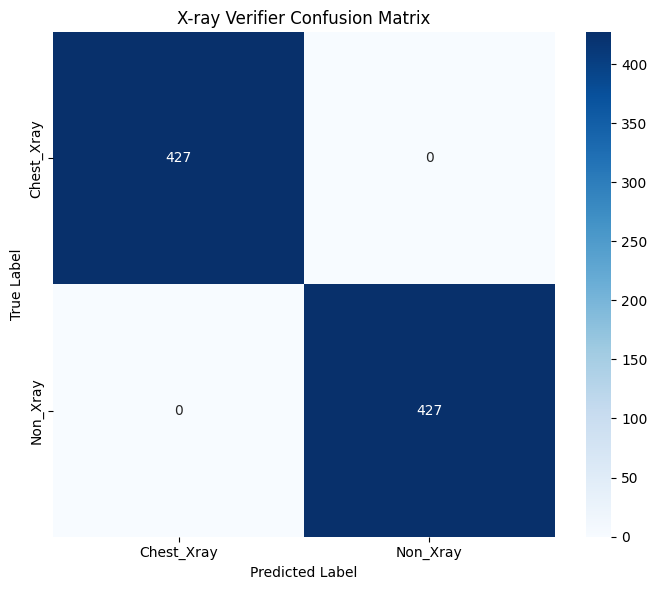

In [50]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# Reset generator

test_generator.reset()


# Predict

y_probability = model.predict(
    test_generator,
    verbose=1
)


# Predicted class

y_pred = np.argmax(
    y_probability,
    axis=1
)


# True class

y_true = test_generator.classes


# ============================================================
# REPORT
# ============================================================

class_names = [
    "Chest_Xray",
    "Non_Xray"
]


print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


print(
    "\nConfusion Matrix:"
)

print(
    cm
)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "X-ray Verifier Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "xray_verifier_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

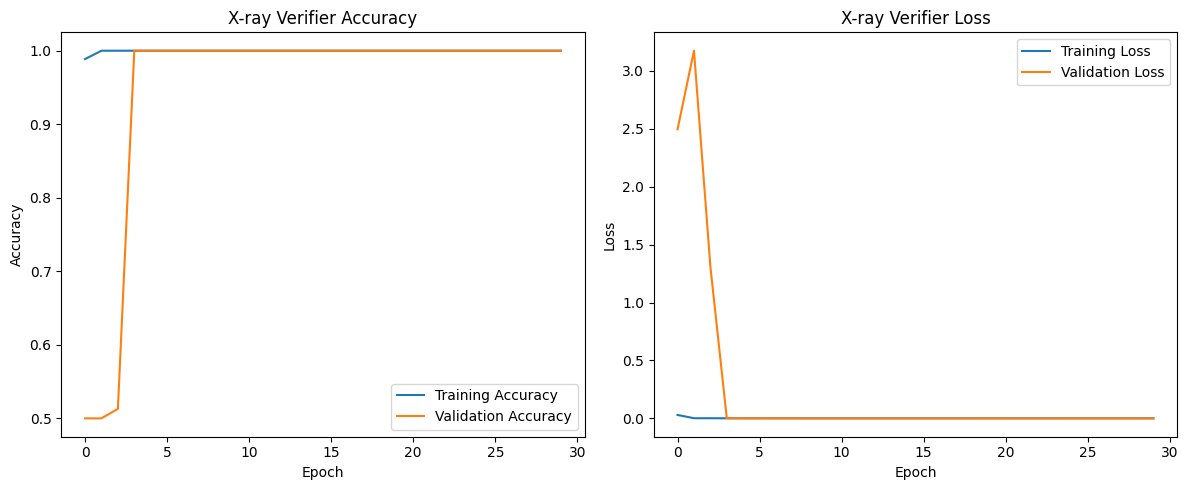

In [51]:
# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(12, 5)
)


# Accuracy

plt.subplot(
    1,
    2,
    1
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "X-ray Verifier Accuracy"
)

plt.legend()


# Loss

plt.subplot(
    1,
    2,
    2
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "X-ray Verifier Loss"
)

plt.legend()


plt.tight_layout()


plt.savefig(
    "/kaggle/working/"
    "xray_verifier_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [52]:
import os

files = [
    "/kaggle/working/best_xray_verifier.weights.h5",
    "/kaggle/working/best_xception_model.keras"
]

for file in files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 ** 2)
        print(f"FOUND: {file}")
        print(f"Size: {size_mb:.2f} MB\n")
    else:
        print(f"NOT FOUND: {file}")

FOUND: /kaggle/working/best_xray_verifier.weights.h5
Size: 7.09 MB

NOT FOUND: /kaggle/working/best_xception_model.keras
